# Normative Uncertainty in IAMs

## Note on Multiobjective Optimization

The multiobjective optimization required for this work **cannot be executed within a notebook environment**. Due to the computational intensity of the optimization algorithm and the need for parallel execution across multiple cores and nodes, it was carried out on a **High Performance Computing (HPC) cluster**.

### Optimization Setup

| Parameter | Value |
|-----------|-------|
| **Algorithm** | Multi-Manager Borg MOEA (**MMBorg**), a parallel island-based multiobjective evolutionary algorithm |
| **Hardware** | ~66 CPU cores distributed across multiple nodes |
| **Function Evaluations** | **100,000 function evaluations (NFEs)** |
| **Population Size** | 100 individuals |
| **Island Configuration** | 5 islands, each running with a different random seed in parallel |
| **Wall Time** | ~40–60 minutes per optimization run (all 5 seeds combined) with the 66-core configuration |

### Parallel Execution with MMBorg

MMBorg employs an **island model** where each island runs an independent instance of the Borg MOEA with a unique random seed. These islands periodically exchange individuals (migration) to maintain diversity while converging toward the Pareto front. With 66 cores:

- **5 islands** × **~13 cores per island** (including the multi-manager workflow overhead)
- Each island evaluates its population in parallel
- The multi-manager architecture coordinates load balancing and migration between islands

The wall time is **proportional to the number of NFEs** and **inversely proportional to available cores**. Reducing cores or increasing NFEs will scale the runtime accordingly.

### Implementation Details

The optimization was executed via the `run_optimization_adaptive()` function from the `run_optimization.py` module, configured through a JSON config file:

```python
from run_optimization import run_optimization_adaptive
from justice.util.enumerations import Optimizer, Evaluator

config_path = "analysis/normative_uncertainty_optimization.json"  # Config used in the Paper

run_optimization_adaptive(
    config_path=config_path,
    nfe=100000,                          # Total function evaluations
    swf=0,                               # Social welfare function index
    seed=5000,                           # Random seed (varied per island)
    datapath="./data",
    optimizer=Optimizer.MMBorgMOEA,      # Multi-Manager Borg MOEA
    population_size=100,
    reference_ssp_rcp_scenario_index=2,  # Reference scenario (SSP245)
    evaluator=Evaluator.SequentialEvaluator,
)
```

Each of the 5 seeds was submitted as a separate job to the HPC cluster, and the results were aggregated to form the final Pareto-optimal solution set.

### HPC Job Submission Script

The SLURM submission script used to launch the optimization on the HPC cluster is located at:


This script allocates 66 cores, sets up the Python environment, and submits 5 parallel jobs (one per seed) with the appropriate NFE and seed arguments.

Follow this instruction for the number of cores needed for different Island Configuration:
Each island uses one **manager** process and **K worker** processes for solution evaluation. In addition, a single **controller** process handles inter-island communication and migration. Therefore, for **N islands** with **K workers per island**, request a total of **N × (K + 1) + 1 MPI processes/nodes** when submitting the job.



### Reproducibility

- **Random seeds:** Fixed seeds (e.g., 5000, 5001, 5002, 5003, 5004) ensure reproducibility across runs
- **Config file:** `analysis/normative_uncertainty_optimization.json` contains all hyperparameters, objective weights, and constraint definitions

##### NOTE: You need to request access to the Borg MOEA. Get access here: http://borgmoea.org/
Alternatively, you can run the optimization with NSGA-II (a more common MOEA) by changing the `optimizer` argument to `Optimizer.NSGAII` which comes integrated with JUSTICE IAM Framework.


## Section 1a: Hypervolume Calculation and Visualization

Tests convergence of the MMBorg multi-master optimization across seeds and SSP scenarios
for both the Prioritarian and Utilitarian social welfare functions.

**Workflow:**

1. **Reference set generation** — combines the final archives from all seeds (MMBorg islands)
   into a single epsilon-nondominated reference set per experiment folder. This global
   reference set serves as the benchmark Pareto front for hypervolume calculations.

2. **Hypervolume computation** — for each seed archive, computes the hypervolume indicator
   at every recorded NFE snapshot against the global reference set. A higher hypervolume
   indicates a better-converged approximation of the Pareto front.

3. **Convergence plots** — plots hypervolume vs. number of function evaluations for all
   seeds within each (SWF, SSP) combination. Convergence across seeds indicates that the
   optimizer has found a stable Pareto front approximation.

**Output:** SVG plots saved to `reproduce/plots/`, one per (SWF, SSP) combination.

In [1]:
# ── Section 1a: Hypervolume Calculation and Visualization ─────────────────────

from solvers.convergence.hypervolume import (
    get_global_reference_set,
    calculate_hypervolume_from_archives,
)
from justice.util.enumerations import WelfareFunction, SSP
from justice.util.visualizer import plot_hypervolume

import glob
import multiprocessing
import os
import re
import warnings

warnings.filterwarnings("ignore")

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path = "data/temporary/NU_DATA/mmBorg/reproduce"
plots_dir = f"{base_path}/plots"
os.makedirs(plots_dir, exist_ok=True)

nfe = 100_000

swf_list = [
    WelfareFunction.PRIORITARIAN,
    WelfareFunction.UTILITARIAN,
]

ssp_list = [
    SSP.SSP1,
    SSP.SSP2,
    SSP.SSP3,
    SSP.SSP4,
    SSP.SSP5,
]

list_of_objectives        = ["welfare", "fraction_above_threshold"]
direction_of_optimization = ["min", "min"]
epsilons                  = [0.00001, 0.001]

# ── HELPER: discover archives in a folder ─────────────────────────────────────
# Matches: {swf_tag}_{nfe}_ref{N}_42_{seed}.tar.gz  (any ref, any seed)
def find_archives(path: str, swf_tag: str, nfe: int) -> list[str]:
    pattern = os.path.join(path, f"{swf_tag}_{nfe}_ref*_42_*.tar.gz")
    files   = sorted(glob.glob(pattern))
    return [os.path.basename(f) for f in files]

# ── REFERENCE SETS ─────────────────────────────────────────────────────────────
print("=" * 60)
print("Generating reference sets")
print("=" * 60)

for swf in swf_list:
    for ssp in ssp_list:
        ssp_name = str(ssp).split(".")[1]
        path     = f"{base_path}/{swf.value[1]}_{ssp_name}"

        archives = find_archives(path, swf.value[1], nfe)
        if not archives:
            print(f"  SKIP  {swf.value[1]}/{ssp_name}  — no archives found")
            continue

        print(f"  {swf.value[1]}/{ssp_name}  ({len(archives)} archives)")

        get_global_reference_set(
            list_of_objectives        = list_of_objectives,
            data_path                 = path,
            swf                       = [swf.value[1]],
            nfe                       = str(nfe),
            epsilons                  = epsilons,
            direction_of_optimization = direction_of_optimization,
            output_data_path          = path,
            saving                    = True,
        )

print()

# ── HYPERVOLUME COMPUTATION ────────────────────────────────────────────────────
# HV CSVs are written to path/hv/ to keep them out of the archive folder.
# load_archives_all_seeds globs the parent folder by prefix — mixing CSVs
# and tar.gz files there causes a ReadError.
print("=" * 60)
print("Computing hypervolumes")
print("=" * 60)

with multiprocessing.Pool() as pool:
    for swf in swf_list:
        for ssp in ssp_list:
            ssp_name = str(ssp).split(".")[1]
            path     = f"{base_path}/{swf.value[1]}_{ssp_name}"
            hv_path  = f"{path}/hv"
            os.makedirs(hv_path, exist_ok=True)

            refset   = f"{swf.value[1]}_reference_set.csv"
            archives = find_archives(path, swf.value[1], nfe)
            if not archives:
                print(f"  SKIP  {swf.value[1]}/{ssp_name}  — no archives found")
                continue

            print(f"  {swf.value[1]}/{ssp_name}  ({len(archives)} archives)")
            for filename in archives:
                print(f"    {filename}")
                calculate_hypervolume_from_archives(
                    list_of_objectives        = list_of_objectives,
                    direction_of_optimization = direction_of_optimization,
                    input_data_path           = path,
                    file_name                 = filename,
                    output_data_path          = hv_path,
                    saving                    = True,
                    global_reference_set      = True,
                    global_reference_set_path = path,
                    global_reference_set_file = refset,
                    pool                      = pool,
                )

print()

# ── HYPERVOLUME PLOTS → reproduce/plots/ ──────────────────────────────────────
print("=" * 60)
print(f"Saving plots → {plots_dir}/")
print("=" * 60)

for swf in swf_list:
    for ssp in ssp_list:
        ssp_name = str(ssp).split(".")[1]
        path     = f"{base_path}/{swf.value[1]}_{ssp_name}"
        hv_path  = f"{path}/hv"

        archives = find_archives(path, swf.value[1], nfe)
        if not archives:
            continue

        refs = sorted({
            int(re.search(r"_ref(\d+)_", f).group(1))
            for f in archives
            if re.search(r"_ref(\d+)_", f)
        })

        for ssp_ref in refs:
            hv_files = sorted(glob.glob(
                os.path.join(hv_path, f"{swf.value[1]}_{nfe}_ref{ssp_ref}_42_*_hv.csv")
            ))

            if not hv_files:
                print(f"  SKIP  {swf.value[1]}/{ssp_name}/ref{ssp_ref}  — no HV files found")
                continue

            print(f"  {swf.value[1]}/{ssp_name}/ref{ssp_ref}  ({len(hv_files)} seeds)")

            fig = plot_hypervolume(
                path_to_data      = hv_path,
                path_to_output    = plots_dir,
                input_data        = {f"{swf.value[1]}_{ssp_name}": [os.path.basename(f) for f in hv_files]},
                yaxis_upper_limit = 1.0,
                width             = 1000,
                height            = 800,
                fontsize          = 20,
                saving            = True,
            )
            # fig.show()

print("\nDone.")

Generating reference sets
  PRIORITARIAN/SSP1  (5 archives)
Loading list of files
Loading archives for:  PRIORITARIAN
Filename:  PRIORITARIAN_100000_ref1_42_3.tar.gz
Matching file: PRIORITARIAN_100000_ref1_42_3.tar.gz
Loading archives from: PRIORITARIAN_100000_ref1_42_3.tar.gz
Max key: 100000
Number of rows in archive: 4
Archives loaded for: PRIORITARIAN_100000_ref1_42_3.tar.gz
Filename:  0_SSP534_PRIORITARIAN_global_temperature_.csv
Filename:  2_SSP370_PRIORITARIAN_global_temperature_.csv
Filename:  0_SSP126_PRIORITARIAN_global_temperature_.csv
Filename:  .DS_Store
Filename:  0_SSP460_PRIORITARIAN_global_temperature_.csv
Filename:  PRIORITARIAN_100000_ref1_42_1.tar.gz
Matching file: PRIORITARIAN_100000_ref1_42_1.tar.gz
Loading archives from: PRIORITARIAN_100000_ref1_42_1.tar.gz
Max key: 100000
Number of rows in archive: 4
Archives loaded for: PRIORITARIAN_100000_ref1_42_1.tar.gz
Filename:  hv
Filename:  2_SSP245_PRIORITARIAN_global_temperature_.csv
Filename:  3_SSP126_PRIORITARIAN_glo

## Section 1b: Pareto Front Re-evaluation and Outcome Mapping

Re-evaluates all Pareto-optimal policy candidates from the reference sets across all
(SWF, SSP) combinations under a set of deep uncertainty scenarios.

**What the script computes:**
For each Pareto-optimal policy index, the model is re-run across 5 SSP forcing scenarios
(SSP126, SSP245, SSP370, SSP460, SSP534) to collect the following outcomes:
- **Global temperature** trajectory over time
- **Utilitarian welfare** trajectory over time
- **Prioritarian welfare** trajectory over time

**Output:** Mapping files written to `reproduce/mapping/`, one per (SWF, SSP) combination.

This mapping serves as the input for regret calculations in the next section.

> ⚠ This step is computationally expensive — expect **30 minutes to several hours** per
> combination depending on the number of policy candidates and available resources.
> Combinations run sequentially; parallelise across different machines if available.

In [1]:
%%bash
# ── Section 1b: Regret Mapping — all SWF × SSP combinations ──────────────────

BASE_PATH="data/temporary/NU_DATA/mmBorg/reproduce/"
SWFS=("PRIORITARIAN" "UTILITARIAN")
SSPS=("SSP1" "SSP2" "SSP3" "SSP4" "SSP5")

for SWF in "${SWFS[@]}"; do
    for SSP in "${SSPS[@]}"; do
        echo "========================================"
        echo "Running: ${SWF} / ${SSP}"
        echo "========================================"
        python justice/util/postprocessing_for_regret_calculations.py \
            "${BASE_PATH}" "${SWF}" "${SSP}"

        if [ $? -ne 0 ]; then
            echo "  ✗ FAILED: ${SWF} / ${SSP}"
        else
            echo "  ✓ Done: ${SWF} / ${SSP}"
        fi
    done
done

echo ""
echo "✓ All done. Outputs in ${BASE_PATH}mapping/"

Running: PRIORITARIAN / SSP1


Selected SWF: WelfareFunction.PRIORITARIAN, SSP: 0
Final output: data/temporary/NU_DATA/mmBorg/reproduce/mapping
Loading data for PRIORITARIAN from data/temporary/NU_DATA/mmBorg/reproduce/PRIORITARIAN_SSP1/PRIORITARIAN_reference_set.csv
Selected policy-indices last 2 columns:
      welfare  fraction_above_threshold
0  398.475097                      0.16
1  398.433140                      0.22
2  398.437763                      0.20
3  398.442591                      0.18

--- [PID 24128] Building JUSTICE for SSP126 (1) ---

--- [PID 24127] Building JUSTICE for SSP245 (2) ---

--- [PID 24126] Building JUSTICE for SSP370 (3) ---

--- [PID 24125] Building JUSTICE for SSP460 (5) ---

--- [PID 24129] Building JUSTICE for SSP534 (6) ---
Welfare:  398.4750969819808
Welfare:  398.4750969819808
Welfare:  398.4750969819808
Welfare:  398.4750969819808
Welfare:  398.4750969819808
index for policy:  0
Fraction above threshold Reeval: 0.44655344655344653
index for policy:  0
Fraction above threshol

Traceback (most recent call last):
  File "<string>", line 1, in <module>
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/palokbiswas/miniforge3/envs/justice-env/lib/python3.9/multiprocessing/spawn.py", line 116, in spawn_main
  File "/Users/palokbiswas/miniforge3/envs/justice-env/lib/python3.9/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Users/palokbiswas/miniforge3/envs/justice-env/lib/python3.9/multiprocessing/spawn.py", line 125, in _main
Traceback (most recent call last):
      File "<string>", line 1, in <module>
exitcode = _main(fd, parent_sentinel)
  File "/Users/palokbiswas/miniforge3/envs/justice-env/lib/python3.9/multiprocessing/spawn.py", line 125, in _main
  File "/Users/palokbiswas/miniforge3/envs/justice-env/lib/python3.9/multiprocessing/spawn.py", line 116, in spawn_main
Traceback (most recent call last):
  File "<string>", line 1, in <module>
    prepare(preparation_data)


Error while terminating subprocess (pid=24121): 


#### Section 1b-ii: Running only a single combination of (SWF, SSP)

In [4]:
%%bash
# ── Section 1b-ii (single run) ───────────────────────────────────────────────────
# Use this to run or re-run a specific SWF / SSP combination.

BASE_PATH="data/temporary/NU_DATA/mmBorg/reproduce/"
SWF="UTILITARIAN" # Specify one of: PRIORITARIAN, UTILITARIAN
SSP="SSP2" # Specify one of: SSP1, SSP2, SSP3, SSP4, SSP5

echo "Running: ${SWF} / ${SSP}"
python justice/util/postprocessing_for_regret_calculations.py \
    "${BASE_PATH}" "${SWF}" "${SSP}"

if [ $? -ne 0 ]; then
    echo "  ✗ FAILED: ${SWF} / ${SSP}"
else
    echo "  ✓ Done: ${SWF} / ${SSP}"
fi

Running: UTILITARIAN / SSP2
Selected SWF: WelfareFunction.UTILITARIAN, SSP: 1
Final output: data/temporary/NU_DATA/mmBorg/reproduce/mapping
Loading data for UTILITARIAN from data/temporary/NU_DATA/mmBorg/reproduce/UTILITARIAN_SSP2/UTILITARIAN_reference_set.csv
Selected policy-indices last 2 columns:
       welfare  fraction_above_threshold
0   103.494986                      0.62
1   103.645088                      0.34
2   103.483105                      0.64
3   103.467961                      0.76
4   103.465072                      0.80
5   103.608493                      0.36
6   103.479852                      0.70
7   103.534661                      0.50
8   103.504900                      0.60
9   103.459036                      0.86
10  103.480534                      0.68
11  103.506200                      0.56
12  103.471677                      0.74
13  103.473309                      0.72
14  103.480930                      0.66
15  103.458890                      0.88
16

### Section 1c: Regret Calculation 

In [2]:
# ── Section 1c: Minimax Regret Calculation ────────────────────────────────────

import json
import numpy as np
import pandas as pd
from pathlib import Path

from justice.util.enumerations import WelfareFunction, SSP
from justice.util.output_data_processor import (
    compute_p90_regret_dataframe,
    minimax_regret_policy,
)

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path      = "data/temporary/NU_DATA/mmBorg/reproduce"
regret_dfs_dir = f"{base_path}/regret_dfs"
Path(regret_dfs_dir).mkdir(parents=True, exist_ok=True)

scenario_list   = ["SSP126", "SSP245", "SSP370", "SSP460", "SSP534"]
save_regret_dfs = True

# SSP reference scenario used during optimisation
BASELINE_SCENARIO = {
    "SSP1": "SSP126",
    "SSP2": "SSP245",
    "SSP3": "SSP370",
    "SSP4": "SSP460",
    "SSP5": "SSP534",
}

# Variable and optimisation direction per (ethical_framing, regret_type)
REGRET_CONFIG = {
    ("UTILITARIAN",  "Temperature_Regret"): ("global_temperature",  "min"),
    ("UTILITARIAN",  "Welfare_Regret")    : ("utilitarian_welfare",  "max"),
    ("PRIORITARIAN", "Temperature_Regret"): ("global_temperature",  "min"),
    ("PRIORITARIAN", "Welfare_Regret")    : ("prioritarian_welfare", "max"),
}

SSP_LIST     = ["SSP1", "SSP2", "SSP3", "SSP4", "SSP5"]
SWF_LIST     = ["UTILITARIAN", "PRIORITARIAN"]
REGRET_TYPES = ["Temperature_Regret", "Welfare_Regret"]

# ── COMPUTE ────────────────────────────────────────────────────────────────────
min_regret_policy_indices = {}

for ssp_key in SSP_LIST:
    baseline_scenario = BASELINE_SCENARIO[ssp_key]
    min_regret_policy_indices[ssp_key] = {}

    for ethical_framing in SWF_LIST:
        min_regret_policy_indices[ssp_key][ethical_framing] = {}

        for regret_type in REGRET_TYPES:
            variable_of_interest, direction_of_interest = REGRET_CONFIG[
                (ethical_framing, regret_type)
            ]

            print(
                f"  {ethical_framing} / {ssp_key} / {regret_type}"
                f"  [{variable_of_interest}, {direction_of_interest}]"
            )


            p90_delta_df = compute_p90_regret_dataframe(
                base_path              = f"{base_path}/{ethical_framing}_{ssp_key}/",
                welfare_function_name  = ethical_framing,
                baseline_scenario      = baseline_scenario,
                scenario_list          = scenario_list,
                variable_of_interest   = variable_of_interest,
                direction_of_interest  = direction_of_interest,
                mapping_subdir         = str(Path(f"{base_path}/mapping").resolve()),
                hdf5_filename_template = f"mapping_{{}}_{ssp_key}.h5",
                save_df                = save_regret_dfs,
                df_output_path         = f"{regret_dfs_dir}/p90_{ethical_framing}_{ssp_key}_{regret_type}.csv",
            )

            policy_idx = minimax_regret_policy(p90_delta_df)
            print(f"    → min regret policy index: {policy_idx}")

            min_regret_policy_indices[ssp_key][ethical_framing][regret_type] = policy_idx

# ── SAVE ───────────────────────────────────────────────────────────────────────
output_file = f"{base_path}/min_regret_policy_indices.json"
with open(output_file, "w") as f:
    json.dump(min_regret_policy_indices, f, indent=4)

print(f"\n✓ Saved → {output_file}")
print(json.dumps(min_regret_policy_indices, indent=4))

  UTILITARIAN / SSP1 / Temperature_Regret  [global_temperature, min]
Saved p90 delta data to data/temporary/NU_DATA/mmBorg/reproduce/regret_dfs/p90_UTILITARIAN_SSP1_Temperature_Regret.csv
    → min regret policy index: 6
  UTILITARIAN / SSP1 / Welfare_Regret  [utilitarian_welfare, max]
Saved p90 delta data to data/temporary/NU_DATA/mmBorg/reproduce/regret_dfs/p90_UTILITARIAN_SSP1_Welfare_Regret.csv
    → min regret policy index: 4
  PRIORITARIAN / SSP1 / Temperature_Regret  [global_temperature, min]
Saved p90 delta data to data/temporary/NU_DATA/mmBorg/reproduce/regret_dfs/p90_PRIORITARIAN_SSP1_Temperature_Regret.csv
    → min regret policy index: 0
  PRIORITARIAN / SSP1 / Welfare_Regret  [prioritarian_welfare, max]
Saved p90 delta data to data/temporary/NU_DATA/mmBorg/reproduce/regret_dfs/p90_PRIORITARIAN_SSP1_Welfare_Regret.csv
    → min regret policy index: 1
  UTILITARIAN / SSP2 / Temperature_Regret  [global_temperature, min]
Saved p90 delta data to data/temporary/NU_DATA/mmBorg/re

## Section 2: Visualizations
### Section 2a: Pareto Fronts 


In [3]:
# ── Section 2a: Pareto Front Visualization ─────────────────────────────────────

import json
import pandas as pd
import plotly.graph_objects as go
from justice.util.enumerations import WelfareFunction, SSP

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path = "data/temporary/NU_DATA/mmBorg/reproduce"
plots_dir = f"{base_path}/plots"

swf_list = [WelfareFunction.PRIORITARIAN, WelfareFunction.UTILITARIAN]
ssp_list = [SSP.SSP1, SSP.SSP2, SSP.SSP3, SSP.SSP4, SSP.SSP5]

# Load min regret indices computed in Section 1c
with open(f"{base_path}/min_regret_policy_indices.json") as f:
    min_regret_policy_indices = json.load(f)

# ── STYLE ──────────────────────────────────────────────────────────────────────
BG_MARKER_STYLE = dict(
    size  = 8,
    color = "lightgray",
    line  = dict(width=0.5, color="gray"),
)

HIGHLIGHT_MARKER_STYLE = {
    "Welfare_Regret"    : dict(symbol="triangle-up", size=14, color="#fc8d62", line=dict(width=1.0, color="#fc8d62")),
    "Temperature_Regret": dict(symbol="square",      size=13, color="#8da0cb", line=dict(width=1.0, color="#8da0cb")),
}

BASE_LAYOUT = dict(
    plot_bgcolor  = "white",
    paper_bgcolor = "white",
    font          = dict(color="black"),
    xaxis_title   = "Welfare (normalized)",
    yaxis_title   = "Temperature (normalized)",
    legend_title  = "Policy",
    width         = 900,
    height        = 600,
)

# ── COMPUTE + PLOT ─────────────────────────────────────────────────────────────
figs = {}   # keyed by (swf_tag, ssp_tag)

for swf in swf_list:
    for ssp in ssp_list:
        swf_tag = swf.value[1]
        ssp_tag = str(ssp).split(".")[1]
        path    = f"{base_path}/{swf_tag}_{ssp_tag}"

        # Load and normalize reference set (last 2 columns: welfare, fraction_above_threshold)
        df = pd.read_csv(f"{path}/{swf_tag}_reference_set.csv").iloc[:, -2:]

        # Normalize welfare (col 0): min-max then invert (higher = better)
        df.iloc[:, 0] = (df.iloc[:, 0] - df.iloc[:, 0].min()) / (df.iloc[:, 0].max() - df.iloc[:, 0].min())
        df.iloc[:, 0] = 1 - df.iloc[:, 0]

        # Normalize fraction_above_threshold (col 1): invert (lower = better)
        df.iloc[:, 1] = (df.iloc[:, 1] - df.iloc[:, 1].max()) / (df.iloc[:, 1].min() - df.iloc[:, 1].max())

        # Get highlight indices from min regret JSON
        highlight_indices = {
            regret_type: min_regret_policy_indices[ssp_tag][swf_tag][regret_type]
            for regret_type in ["Welfare_Regret", "Temperature_Regret"]
        }
        all_highlight_idx = set(highlight_indices.values())
        df_bg = df[~df.index.isin(all_highlight_idx)]

        # ── PLOT ──
        fig = go.Figure()

        fig.add_trace(go.Scatter(
            x          = df_bg.iloc[:, 1],
            y          = df_bg.iloc[:, 0],
            mode       = "markers",
            marker     = BG_MARKER_STYLE,
            name       = "Other policies",
            showlegend = True,
        ))

        for regret_type, idx in highlight_indices.items():
            row = df.loc[idx]
            fig.add_trace(go.Scatter(
                x          = [row.iloc[1]],
                y          = [row.iloc[0]],
                mode       = "markers",
                marker     = HIGHLIGHT_MARKER_STYLE[regret_type],
                name       = regret_type.replace("_", " "),
                showlegend = True,
            ))

        fig.update_layout(
            **BASE_LAYOUT,
            title = dict(text=f"{swf_tag} — {ssp_tag}", x=0.5),
        )
        fig.update_xaxes(showline=True, linewidth=2, linecolor="black", tickfont=dict(size=14))
        fig.update_yaxes(showline=True, linewidth=2, linecolor="black", tickfont=dict(size=14))

        figs[(swf_tag, ssp_tag)] = fig

        # ── EXPORT ──
        save_path = f"{plots_dir}/{swf_tag}_{ssp_tag}_pareto_front.svg"
        fig.write_image(save_path)
        print(f"  ✓ {save_path}")

  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/PRIORITARIAN_SSP1_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/PRIORITARIAN_SSP2_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/PRIORITARIAN_SSP3_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/PRIORITARIAN_SSP4_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/PRIORITARIAN_SSP5_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/UTILITARIAN_SSP1_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/UTILITARIAN_SSP2_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/UTILITARIAN_SSP3_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/UTILITARIAN_SSP4_pareto_front.svg
  ✓ data/temporary/NU_DATA/mmBorg/reproduce/plots/UTILITARIAN_SSP5_pareto_front.svg


## Section 3a: Policy Reevaluation and Variable Extraction

For each minimax-regret policy identified in Section 1c, this block re-runs the full
JUSTICE model across all 5 deep uncertainty scenarios (SSP126–SSP534) to extract
time-series outputs for downstream visualization and analysis.

**What this block computes:**
- **Emissions** — global total emissions trajectory (GtCO₂) over 2015–2300
- **Constrained emission control rate** — the policy-prescribed abatement rate per region over time

For each (SWF × SSP × regret type) combination, a temporary HDF5 file is written to
`reproduce/`, variables are extracted as `.npy` arrays, and the HDF5 is deleted to
free disk space.

**Output:** `.npy` files saved to `reproduce/model_outputs/`, named as:
`{SWF}_{SSP}_{RegretType}_{variable}_{scenario}.npy`

> ⚠ **This block is computationally expensive — expect 40–60 minutes total** for all
> 20 combinations (2 SWFs × 5 SSPs × 2 regret types). It also generates several GBs
> of intermediate data. Ensure at least **100 GB of free disk space** before running.
> The temporary HDF5 files are deleted automatically after extraction.

In [1]:
# ── Section 3: Policy Reevaluation and Variable Extraction ────────────────────

import json
import os
import pandas as pd
from pathlib import Path

from justice.util.output_data_processor import (
    reevaluate_optimal_policy,
    reevaluated_optimal_policy_variable_extractor,
)
from justice.util.model_time import TimeHorizon
from justice.util.data_loader import DataLoader
from justice.util.enumerations import WelfareFunction, SSP

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path        = "data/temporary/NU_DATA/mmBorg/reproduce"
model_output_dir = f"{base_path}/model_outputs"
Path(model_output_dir).mkdir(parents=True, exist_ok=True)

scenario_list  = ["SSP126", "SSP245", "SSP370", "SSP460", "SSP534"]

VARIABLE_CONFIG = {
    "emissions"                        : 3,
    "constrained_emission_control_rate": 3,
}

# ── SETUP ──────────────────────────────────────────────────────────────────────
data_loader   = DataLoader()
region_list   = data_loader.REGION_LIST
time_horizon  = TimeHorizon(
    start_year    = 2015,
    end_year      = 2300,
    data_timestep = 5,
    timestep      = 1,
)
list_of_years = time_horizon.model_time_horizon

with open(f"{base_path}/min_regret_policy_indices.json") as f:
    min_regret_policy_indices = json.load(f)

# ── REEVALUATE + EXTRACT ───────────────────────────────────────────────────────
for ssp_key, ethical_data in min_regret_policy_indices.items():
    for ethical_framing, regret_data in ethical_data.items():
        for regret_type, policy_index in regret_data.items():

            swf  = WelfareFunction[ethical_framing]
            path = f"{base_path}/{ethical_framing}_{ssp_key}/"

            print(f"\n{'='*60}")
            print(f"  {ethical_framing} / {ssp_key} / {regret_type}  (policy idx {policy_index})")
            print(f"{'='*60}")

            # ── REEVALUATE ─────────────────────────────────────────────────────
            # path_to_output uses trailing slash — function concatenates without sep
            reevaluate_optimal_policy(
                input_data                = [f"{swf.value[1]}_reference_set.csv"],
                path_to_rbf_weights       = path,
                path_to_output            = f"{base_path}/",
                direction_of_optimization = ["min", "min"],
                rbf_policy_index          = policy_index,
                list_of_objectives        = ["welfare", "fraction_above_threshold"],
                scenario_list             = scenario_list,
                reference_scenario        = ssp_key,
                regret_type               = regret_type,
            )

            # h5 written to base_path/ by reevaluate_optimal_policy
            h5_name = (
                f"{ethical_framing}_reference_set"
                f"_ref_{ssp_key}_{regret_type}_idx{policy_index}.h5"
            )

            # ── EXTRACT VARIABLES ──────────────────────────────────────────────
            for variable_name, data_shape in VARIABLE_CONFIG.items():
                output_stem = f"{ethical_framing}_{ssp_key}_{regret_type}_{variable_name}"

                reevaluated_optimal_policy_variable_extractor(
                    scenario_list     = scenario_list,
                    region_list       = region_list,
                    list_of_years     = list_of_years,
                    path_to_data      = base_path,
                    path_to_output    = model_output_dir,
                    variable_name     = variable_name,
                    data_shape        = data_shape,
                    no_of_ensembles   = 1001,
                    input_data        = [h5_name],
                    output_file_names = [output_stem],
                )
                print(f"  ✓ {model_output_dir}/{output_stem}_<scenario>.npy")

            # ── CLEANUP: delete temporary h5 ──────────────────────────────────
            h5_full = f"{base_path}/{h5_name}"
            if os.path.exists(h5_full):
                os.remove(h5_full)
                print(f"  🗑  Deleted: {h5_name}")
            else:
                print(f"  ⚠ h5 not found for cleanup: {h5_full}")

/Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



  UTILITARIAN / SSP1 / Temperature_Regret  (policy idx 6)
index for policy:  6
1 SSP126
Welfare:  100.85847681507852
Keys of the scenario data:  dict_keys(['SSP126'])
2 SSP245
Welfare:  100.85847681507852
Keys of the scenario data:  dict_keys(['SSP126', 'SSP245'])
3 SSP370
Welfare:  100.85847681507852
Keys of the scenario data:  dict_keys(['SSP126', 'SSP245', 'SSP370'])
5 SSP460
Welfare:  100.85847681507852
Keys of the scenario data:  dict_keys(['SSP126', 'SSP245', 'SSP370', 'SSP460'])
6 SSP534
Welfare:  100.85847681507852
Keys of the scenario data:  dict_keys(['SSP126', 'SSP245', 'SSP370', 'SSP460', 'SSP534'])
Saving file as  UTILITARIAN_reference_set
File saved as UTILITARIAN_reference_set_ref_SSP1_Temperature_Regret_idx6 at location data/temporary/NU_DATA/mmBorg/reproduce/
Directory:  /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE
SSP126
File saved as UTILITARIAN_SSP1_Temperature_Regret_emissions_idx6_SSP126_emissions at location data/temporary/NU_DATA/mmBorg/reproduce/model_o

### Section 3b:Emission Pathway Visualization

In [1]:
# ── Section 3b: Emission Pathway Visualization ────────────────────────────────

import json
import numpy as np
import pandas as pd
from justice.util.visualizer import plot_comparison_with_boxplots
from justice.util.enumerations import WelfareFunction, SSP

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path        = "data/temporary/NU_DATA/mmBorg/reproduce"
model_output_dir = f"{base_path}/model_outputs"
plots_dir        = f"{base_path}/plots"

variable_name = "emissions"

scenario_list  = ["SSP126", "SSP245", "SSP370", "SSP460", "SSP534"]
scenario_labels = ["SSP1", "SSP2", "SSP3", "SSP4", "SSP5"]

with open(f"{base_path}/min_regret_policy_indices.json") as f:
    min_regret_policy_indices = json.load(f)

# ── STYLE ──────────────────────────────────────────────────────────────────────
LINE_COLORS = [
    "rgba(141,211,199, 1)",
    "rgba(254,217,166, 1)",
    "rgba(190,186,218, 1)",
    "rgba(128,177,211, 1)",
    "rgba(251,128,114, 1)",
]

FILL_COLORS = [
    "rgba(141,211,199, 0.4)",
    "rgba(254,217,166, 0.4)",
    "rgba(190,186,218, 0.4)",
    "rgba(128,177,211, 0.4)",
    "rgba(251,128,114, 0.4)",
]

PLOT_STYLE = dict(
    start_year                = 2015,
    end_year                  = 2300,
    data_timestep             = 5,
    timestep                  = 1,
    visualization_start_year  = 2015,
    visualization_end_year    = 2100,
    yaxis_range               = [0, 80],
    plot_title                = " ",
    xaxis_title               = "Year",
    yaxis_title               = "Global Emissions (GtCO₂)",
    template                  = "plotly_white",
    width                     = 1000,
    height                    = 700,
    saving                    = True,
    show_red_dashed_line      = False,
    show_interquartile_range  = True,
    first_plot_proportion     = [0, 0.75],
    second_plot_proportion    = [0.85, 1],
    transpose_data            = True,
    show_min_max              = False,
    dtick                     = 10,
)

# ── PLOT ───────────────────────────────────────────────────────────────────────
figs = {}   # keyed by (ethical_framing, ssp_key, regret_type)

for ssp_key, ethical_data in min_regret_policy_indices.items():
    for ethical_framing, regret_data in ethical_data.items():
        for regret_type, policy_index in regret_data.items():

            # Build data_paths using Option A naming from Section 3a
            data_paths = [
                f"{model_output_dir}/{ethical_framing}_{ssp_key}_{regret_type}"
                f"_{variable_name}_idx{policy_index}_{scenario}_{variable_name}.npy"
                for scenario in scenario_list
            ]

            print(f"  {ethical_framing} / {ssp_key} / {regret_type}")

            fig = plot_comparison_with_boxplots(
                data_paths        = data_paths,
                labels            = scenario_labels,
                output_path       = plots_dir,
                output_name_suffix= f"{ethical_framing}_{ssp_key}_{regret_type}",
                linecolors        = LINE_COLORS,
                colors            = FILL_COLORS,
                **PLOT_STYLE,
            )

            figs[(ethical_framing, ssp_key, regret_type)] = fig
            fig.show()

print("\n✓ All emission pathway plots saved.")

  UTILITARIAN / SSP1 / Temperature_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  UTILITARIAN / SSP1 / Welfare_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  PRIORITARIAN / SSP1 / Temperature_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  PRIORITARIAN / SSP1 / Welfare_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  UTILITARIAN / SSP2 / Temperature_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


...

  UTILITARIAN / SSP5 / Temperature_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  UTILITARIAN / SSP5 / Welfare_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  PRIORITARIAN / SSP5 / Temperature_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)


  PRIORITARIAN / SSP5 / Welfare_Regret
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)
Data is 3D
Shape of data:  (57, 286, 1001)
Shape of data after summing:  (286, 1001)



✓ All emission pathway plots saved.


### Section 3c:Visualize the Distribution of Emission Control Rates across SSPs

In [1]:
# ── Section 3c: Emission Control Rate Choropleth Visualization ────────────────

import json
import numpy as np
import plotly.express as px
from justice.util.visualizer import plot_choropleth_2D_data
from justice.util.enumerations import WelfareFunction, SSP

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path        = "data/temporary/NU_DATA/mmBorg/reproduce"
model_output_dir = f"{base_path}/model_outputs"
plots_dir        = f"{base_path}/plots"

variable_name  = "constrained_emission_control_rate"
scenario_list  = ["SSP126", "SSP245", "SSP370", "SSP460", "SSP534"]

with open(f"{base_path}/min_regret_policy_indices.json") as f:
    min_regret_policy_indices = json.load(f)

# ── STYLE ──────────────────────────────────────────────────────────────────────
CHOROPLETH_STYLE = dict(
    projection          = "equal earth",
    colourmap           = px.colors.sequential.Reds,
    year_to_visualize   = 2050,
    data_label          = "Emission Control Rate",
    legend_label        = "",
    data_normalization  = True,
    saving              = True,
    show_colorbar       = False,
    normalized_colorbar = True,
    plot_saving_format  = "svg",
)

# ── PLOT ───────────────────────────────────────────────────────────────────────
figs = {}   # keyed by (ethical_framing, ssp_key, regret_type)

for ssp_key, ethical_data in min_regret_policy_indices.items():
    for ethical_framing, regret_data in ethical_data.items():
        for regret_type, policy_index in regret_data.items():

            input_data_path_list = [
                f"{ethical_framing}_{ssp_key}_{regret_type}"
                f"_{variable_name}_idx{policy_index}_{scenario}_{variable_name}.npy"
                for scenario in scenario_list
            ]

            print(f"  {ethical_framing} / {ssp_key} / {regret_type}  (policy idx {policy_index})")

            fig, prior_data = plot_choropleth_2D_data(
                path_to_data         = f"{model_output_dir}/",
                path_to_output       = plots_dir,
                input_data_path_list = input_data_path_list,
                **CHOROPLETH_STYLE,
            )

            figs[(ethical_framing, ssp_key, regret_type)] = fig
            fig.show()

print("\n✓ All emission control rate choropleth plots saved.")

  UTILITARIAN / SSP1 / Temperature_Regret  (policy idx 6)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  UTILITARIAN / SSP1 / Welfare_Regret  (policy idx 4)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  PRIORITARIAN / SSP1 / Temperature_Regret  (policy idx 0)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  PRIORITARIAN / SSP1 / Welfare_Regret  (policy idx 1)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  UTILITARIAN / SSP2 / Temperature_Regret  (policy idx 25)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


...

  UTILITARIAN / SSP5 / Temperature_Regret  (policy idx 28)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  UTILITARIAN / SSP5 / Welfare_Regret  (policy idx 25)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  PRIORITARIAN / SSP5 / Temperature_Regret  (policy idx 5)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4


  PRIORITARIAN / SSP5 / Welfare_Regret  (policy idx 2)
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
Taking average over the last dimension.
0
1
2
3
4



✓ All emission control rate choropleth plots saved.


## Section 4: Feature Importance and Sensitivity Analysis

Quantifies how much each design dimension — **reference scenario for optimization**,
**regret type**, **reevaluation scenario**, and **social welfare function** — contributes
to explaining variance in abated emissions across the 1001 ensemble members of FaIR Climate Model.

**Workflow:**

1. **Long DataFrame construction** — for every (SWF × SSP × regret type) combination of shape (10410400, 9),
   loads the reevaluated emissions arrays from `model_outputs/`, computes abated
   emissions relative to a no-policy baseline, aggregates them to 12 world regions,
   and assembles a single tidy DataFrame with columns:
   `Optimization`, `Regret`, `Scenario`, `Welfare`, `Region`, `Year`, `Sample`, `AbatedEmission`.

2. **CatBoost regression with cross-validation** — for each year of interest
   (2030–2100), a gradient-boosted tree model is trained with 5-fold cross-validation
   and early stopping. The four categorical design dimensions are used as features
   and the abated emission value per sample as the target. Two passes are run:
   one for **global** scope (emissions summed across regions) and one for **regional**
   scope (one model per region × year).

3. **SHAP feature importance** — mean absolute SHAP values are computed on each
   validation fold and averaged across folds, then recomputed on the full dataset
   using the final model. This gives a robust, model-consistent measure of which
   design dimension drives abatement outcomes most at each point in time.

**Output:** Normalized SHAP importance CSVs saved to `reproduce/sensitivity_analysis/`:

sensitivity_analysis/
├── global/raw/
│ ├── global_2030_shap_full.csv
│ ├── global_2050_shap_full.csv
│ └── ...
└── regional/raw/
├── Africa_2030_shap_full.csv
├── Europe_2050_shap_full.csv
└── ...


> ⚠ **This block is computationally expensive — expect 50–60 minutes total.**
> Regional scope is significantly slower than global due to the number of
> per-region models fitted (12 regions × 8 years × 5 CV folds). Consider running
> global scope first to verify outputs before launching the regional pass.

In [1]:
# ── Section 4: Feature Importance / Sensitivity Analysis ─────────────────────

from justice.util.feature_importance import build_long_dataframe, run_all_ml_importance

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path        = "data/temporary/NU_DATA/mmBorg/reproduce"
model_output_dir = f"{base_path}/model_outputs"
sensitivity_dir  = f"{base_path}/sensitivity_analysis"

years = (2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100)

ML_PARAMS = dict(
    depth               = 6,
    learning_rate       = 0.05,
    n_estimators        = 800,
    l2_leaf_reg         = 3.0,
    loss_function       = "RMSE",
    random_seed         = 42,
    od_type             = "Iter",
    od_wait             = 50,
    use_best_model      = True,
    verbose             = False,
    allow_writing_files = False,
)

# ── BUILD LONG DATAFRAME ───────────────────────────────────────────────────────
long_df = build_long_dataframe(
    base_path             = f"{base_path}/",
    model_output_dir      = model_output_dir,
    region_mapping_path   = "data/input/12_regions.json",
    rice_region_dict_path = "data/input/rice50_regions_dict.json",
    years_of_interest     = years,
)

print(f"Long DF shape: {long_df.shape}")

# ── RUN IMPORTANCE: GLOBAL ─────────────────────────────────────────────────────
print("\n" + "="*60)
print("Running Global scope...")
print("="*60)

results_global = run_all_ml_importance(
    long_df          = long_df,
    years            = years,
    target_stats     = ("raw",),
    output_dir       = sensitivity_dir,
    cv_folds         = 5,
    random_state     = 42,
    model_params     = ML_PARAMS,
    normalized_plots = True,
    model_type       = "final",
    scope            = "global",
)

print(f"  ✓ Global CSVs → {sensitivity_dir}/global/raw/")

# ── RUN IMPORTANCE: REGIONAL ───────────────────────────────────────────────────
print("\n" + "="*60)
print("Running Regional scope...")
print("="*60)

results_regional = run_all_ml_importance(
    long_df          = long_df,
    years            = years,
    target_stats     = ("raw",),
    output_dir       = sensitivity_dir,
    cv_folds         = 5,
    random_state     = 42,
    model_params     = ML_PARAMS,
    normalized_plots = True,
    model_type       = "final",
    scope            = "regional",
)

print(f"  ✓ Regional CSVs → {sensitivity_dir}/regional/raw/")

# ── MERGE ──────────────────────────────────────────────────────────────────────
results = {
    stat: {**results_global[stat], **results_regional[stat]}
    for stat in results_global
}

print(f"\n✓ Sensitivity analysis complete.")
print(f"  Output structure:")
print(f"    {sensitivity_dir}/global/raw/   — global SHAP CSVs per year")
print(f"    {sensitivity_dir}/regional/raw/ — regional SHAP CSVs per region × year")

Long DF shape: (10410400, 9)

Running Global scope...
Saving plots to: /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/NU_DATA/mmBorg/reproduce/sensitivity_analysis/global/raw
Saving feature importance data to: /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/NU_DATA/mmBorg/reproduce/sensitivity_analysis/global/raw/global_2030_shap_full.csv
Saving feature importance data to: /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/NU_DATA/mmBorg/reproduce/sensitivity_analysis/global/raw/global_2040_shap_full.csv
Saving feature importance data to: /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/NU_DATA/mmBorg/reproduce/sensitivity_analysis/global/raw/global_2050_shap_full.csv
Saving feature importance data to: /Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/NU_DATA/mmBorg/reproduce/sensitivity_analysis/global/raw/global_2060_shap_full.csv
Saving feature importance data to: /Users/palokbiswas/Desktop/pol

### Section 4b: Visualize Feature Importance Results

In [1]:
# ── Section 4b: SHAP Importance Visualization ─────────────────────────────────

from justice.util.visualizer import render_all_grouped_stacked_charts

# ── CONFIG ─────────────────────────────────────────────────────────────────────
base_path       = "data/temporary/NU_DATA/mmBorg/reproduce"
sensitivity_dir = f"{base_path}/sensitivity_analysis"
plots_dir       = f"{base_path}/plots"

years = (2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100)

GROUP_MAP = {
    "Deep Uncertainty"      : ["Scenario"],
    "Normative Uncertainty" : ["Optimization", "Welfare", "Regret"],
    "Stochastic Uncertainty": ["Sample"],
}

# ── PLOT: GLOBAL ───────────────────────────────────────────────────────────────
print("Rendering global SHAP charts...")

render_all_grouped_stacked_charts(
    base_dir   = sensitivity_dir,
    scope      = "global",
    stat       = "raw",
    model_type = "final",
    years      = years,
    group_map  = GROUP_MAP,
    output_dir = f"{plots_dir}/shap_global",
)

print(f"  ✓ Global SHAP plots → {plots_dir}/shap_global/")

# ── PLOT: REGIONAL ─────────────────────────────────────────────────────────────
print("Rendering regional SHAP charts...")

render_all_grouped_stacked_charts(
    base_dir   = sensitivity_dir,
    scope      = "regional",
    stat       = "raw",
    model_type = "final",
    years      = years,
    group_map  = GROUP_MAP,
    output_dir = f"{plots_dir}/shap_regional",
)

print(f"  ✓ Regional SHAP plots → {plots_dir}/shap_regional/")


Rendering global SHAP charts...
[info] Saving figure to data/temporary/NU_DATA/mmBorg/reproduce/plots/shap_global/global_raw_final_stacked.svg
  ✓ Global SHAP plots → data/temporary/NU_DATA/mmBorg/reproduce/plots/shap_global/
Rendering regional SHAP charts...
[info] Saving figure to data/temporary/NU_DATA/mmBorg/reproduce/plots/shap_regional/regional_raw_final_stacked_Brazil.svg
[info] Saving figure to data/temporary/NU_DATA/mmBorg/reproduce/plots/shap_regional/regional_raw_final_stacked_China.svg
[info] Saving figure to data/temporary/NU_DATA/mmBorg/reproduce/plots/shap_regional/regional_raw_final_stacked_Europe.svg
[info] Saving figure to data/temporary/NU_DATA/mmBorg/reproduce/plots/shap_regional/regional_raw_final_stacked_Gulf_Countries.svg
[info] Saving figure to data/temporary/NU_DATA/mmBorg/reproduce/plots/shap_regional/regional_raw_final_stacked_India.svg
[info] Saving figure to data/temporary/NU_DATA/mmBorg/reproduce/plots/shap_regional/regional_raw_final_stacked_Other_High_In

### Section 4c: Visualizing the spatiotemporal distribution of ShAP importance

In [1]:
from pathlib import Path
from justice.util.visualizer import generate_uncertainty_visualizations

# ── Root ──────────────────────────────────────────────────────────────────────
root = Path("data/temporary/NU_DATA/mmBorg/reproduce")

sensitivity_dir     = str(root / "sensitivity_analysis")
plots_dir           = str(root / "plots")
region_mapping_path = "data/input/12_regions.json"
output_dir          = root / "plots" / "uncertainty_viz"
output_dir.mkdir(parents=True, exist_ok=True)

# ── Run ───────────────────────────────────────────────────────────────────────
fig_map, results = generate_uncertainty_visualizations(
    base_dir            = sensitivity_dir,
    region_mapping_path = region_mapping_path,
    stat                = "raw",
    model_type          = "final",
    years               = (2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100), #(2030, 2050, 2070, 2100),
    ternary_scale       = 8,
    quantize            = True,
    annotate_points     = True,
    marker_size         = 40,
    jitter_strength     = 0.02,
    random_state        = 0,
    output_dir          = str(output_dir),
)

print("Saved figures:")
for path in results:
    print(f"  {path}")

fig_map.show()

Saved figures:
  2030
  2040
  2050
  2060
  2070
  2080
  2090
  2100


## ---------------------------------------------------------------------------------------

#### Supplementary: Correlation Analysis of Prioritarian optimized under SSP4

CORRELATION ANALYSIS — PRIORITARIAN SSP4
                             seed  n  pearson_r  pearson_p  spearman_r  spearman_p
PRIORITARIAN_100000_ref5_42_0.tar 16   0.778414   0.000383   -0.283275    0.287710
PRIORITARIAN_100000_ref5_42_1.tar 32   0.366127   0.039312   -0.414218    0.018427
PRIORITARIAN_100000_ref5_42_2.tar 22   0.739755   0.000083   -0.550860    0.007886
PRIORITARIAN_100000_ref5_42_3.tar 28   0.517486   0.004799   -0.466681    0.012298
PRIORITARIAN_100000_ref5_42_4.tar 29   0.376014   0.044401   -0.382068    0.040822

           scope   n  pearson_r    pearson_p  spearman_r  spearman_p
pooled_all_seeds 127   0.530478 1.411844e-10   -0.400219    0.000003

FINAL NFE SPREAD SUMMARY
          dataset  n_solutions_final  welfare_min  welfare_max  welfare_range  welfare_std  fraction_above_threshold_min  fraction_above_threshold_max  fraction_above_threshold_range  fraction_above_threshold_std
PRIORITARIAN SSP4                 10   498.157262   498.808927       0.651665     0

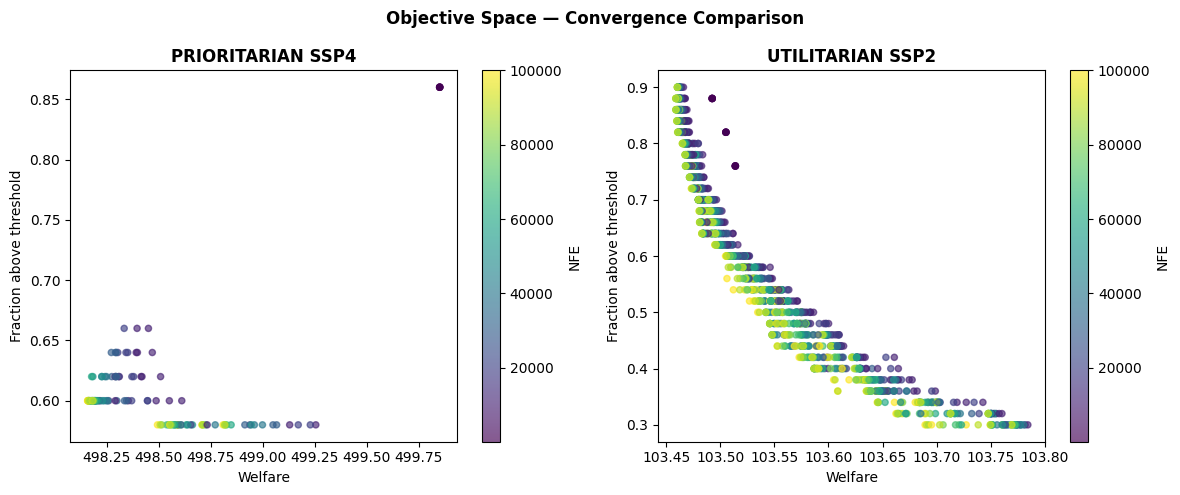

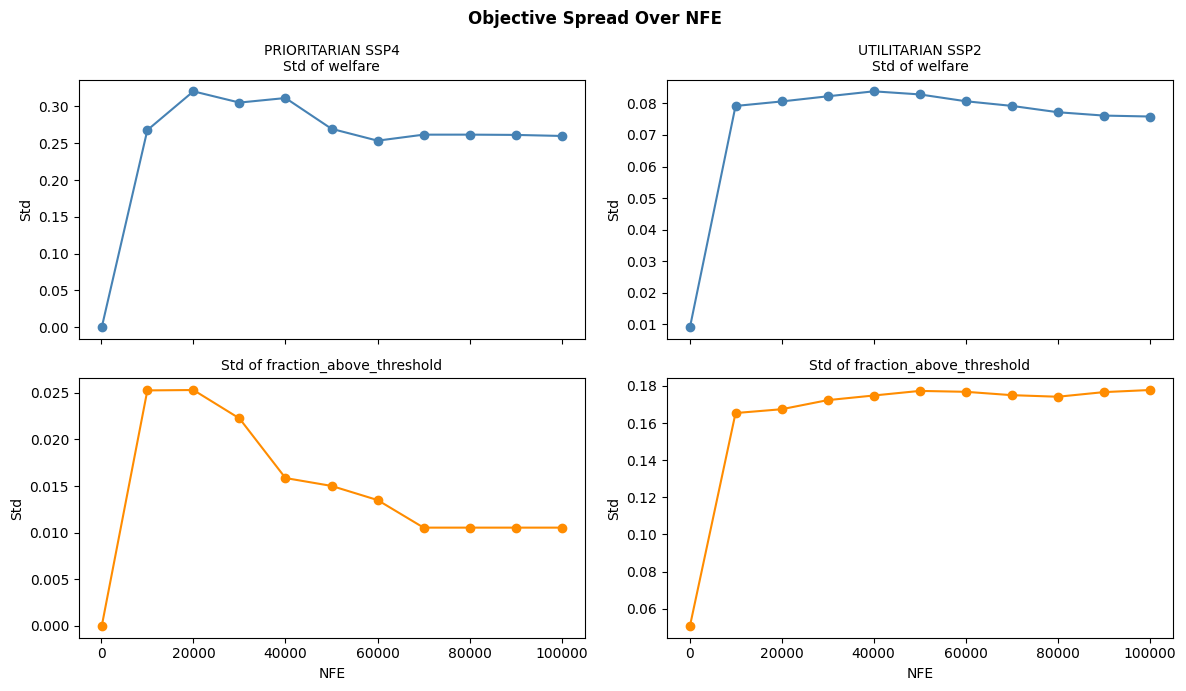

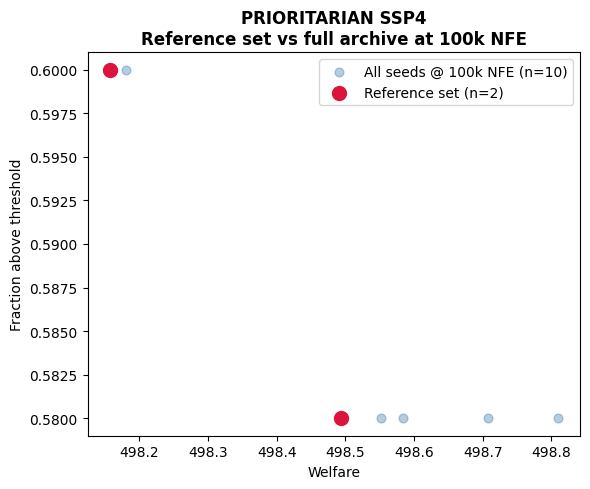


Saved outputs to:
/Users/palokbiswas/Desktop/pollockdevis_git/JUSTICE/data/temporary/NU_DATA/mmBorg/reproduce/plots


In [7]:
import tarfile
import io
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ── CONFIG ────────────────────────────────────────────────────────────────────
root = Path("data/temporary/NU_DATA/mmBorg/reproduce")
plots_dir = root / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

obj_x = "welfare"
obj_y = "fraction_above_threshold"

# Optional comparison case
comparison_folder = root / "UTILITARIAN_SSP2"

# ── HELPER ────────────────────────────────────────────────────────────────────
def load_folder(folder: Path) -> pd.DataFrame:
    records = []
    for archive_path in sorted(folder.glob("*.tar.gz")):
        seed = archive_path.stem
        with tarfile.open(archive_path, "r:gz") as tar:
            for member in tar.getmembers():
                if not member.name.endswith(".csv"):
                    continue
                try:
                    nfe = int(Path(member.name).stem)
                except ValueError:
                    continue
                f = tar.extractfile(member)
                if f is None:
                    continue
                df = pd.read_csv(io.TextIOWrapper(f))
                df["seed"] = seed
                df["nfe"] = nfe
                records.append(df)

    if not records:
        raise ValueError(f"No archive CSV records found in {folder}")

    return pd.concat(records, ignore_index=True)

# ── LOAD ──────────────────────────────────────────────────────────────────────
df_pri_ssp4 = load_folder(root / "PRIORITARIAN_SSP4")

datasets = {
    "PRIORITARIAN SSP4": df_pri_ssp4,
}

if comparison_folder.exists():
    df_uti_ssp2 = load_folder(comparison_folder)
    datasets["UTILITARIAN SSP2"] = df_uti_ssp2

# ── 1) CORRELATION ANALYSIS: PRIORITARIAN SSP4 ───────────────────────────────
df_obj = df_pri_ssp4[["seed", "nfe", obj_x, obj_y]].copy()

corr_rows = []
for seed, df_seed in df_obj.groupby("seed"):
    w = df_seed[obj_x].values
    f = df_seed[obj_y].values
    if len(w) < 3:
        continue

    pearson_r, pearson_p = stats.pearsonr(w, f)
    spearman_r, spearman_p = stats.spearmanr(w, f)

    corr_rows.append({
        "seed": seed,
        "n": len(df_seed),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
    })

corr_df = pd.DataFrame(corr_rows).sort_values("seed").reset_index(drop=True)

pool_pearson_r, pool_pearson_p = stats.pearsonr(df_obj[obj_x], df_obj[obj_y])
pool_spearman_r, pool_spearman_p = stats.spearmanr(df_obj[obj_x], df_obj[obj_y])

corr_pooled_df = pd.DataFrame([{
    "scope": "pooled_all_seeds",
    "n": len(df_obj),
    "pearson_r": pool_pearson_r,
    "pearson_p": pool_pearson_p,
    "spearman_r": pool_spearman_r,
    "spearman_p": pool_spearman_p,
}])

corr_df.to_csv(plots_dir / "prioritarian_ssp4_correlation_by_seed.csv", index=False)
corr_pooled_df.to_csv(plots_dir / "prioritarian_ssp4_correlation_pooled.csv", index=False)

print("=" * 72)
print("CORRELATION ANALYSIS — PRIORITARIAN SSP4")
print("=" * 72)
print(corr_df.to_string(index=False))
print()
print(corr_pooled_df.to_string(index=False))

# ── 2) FINAL-NFE SPREAD SUMMARY ───────────────────────────────────────────────
final_spread_rows = []
for name, df in datasets.items():
    final = df[df["nfe"] == 100000].copy()
    if final.empty:
        continue

    final_spread_rows.append({
        "dataset": name,
        "n_solutions_final": len(final),
        f"{obj_x}_min": final[obj_x].min(),
        f"{obj_x}_max": final[obj_x].max(),
        f"{obj_x}_range": final[obj_x].max() - final[obj_x].min(),
        f"{obj_x}_std": final[obj_x].std(),
        f"{obj_y}_min": final[obj_y].min(),
        f"{obj_y}_max": final[obj_y].max(),
        f"{obj_y}_range": final[obj_y].max() - final[obj_y].min(),
        f"{obj_y}_std": final[obj_y].std(),
    })

final_spread_df = pd.DataFrame(final_spread_rows)
final_spread_df.to_csv(plots_dir / "final_nfe_spread_summary.csv", index=False)

print("\n" + "=" * 72)
print("FINAL NFE SPREAD SUMMARY")
print("=" * 72)
print(final_spread_df.to_string(index=False))

# ── 3) PRIORITARIAN REFERENCE-SET SUMMARY ACROSS SSPs ────────────────────────
ref_rows = []
for ssp in ["SSP1", "SSP2", "SSP3", "SSP4", "SSP5"]:
    folder = root / f"PRIORITARIAN_{ssp}"
    ref_path = folder / "PRIORITARIAN_reference_set.csv"
    if not ref_path.exists():
        continue

    ref = pd.read_csv(ref_path)
    ref_rows.append({
        "ssp": ssp,
        "n_reference_solutions": len(ref),
        f"{obj_y}_min": ref[obj_y].min(),
        f"{obj_y}_max": ref[obj_y].max(),
        f"{obj_y}_range": ref[obj_y].max() - ref[obj_y].min(),
        f"{obj_x}_min": ref[obj_x].min(),
        f"{obj_x}_max": ref[obj_x].max(),
        f"{obj_x}_range": ref[obj_x].max() - ref[obj_x].min(),
    })

ref_summary_df = pd.DataFrame(ref_rows)
ref_summary_df.to_csv(plots_dir / "prioritarian_reference_set_summary_across_ssps.csv", index=False)

print("\n" + "=" * 72)
print("PRIORITARIAN REFERENCE SET SUMMARY ACROSS SSPs")
print("=" * 72)
print(ref_summary_df.to_string(index=False))

# ── 4) SSP4 REFERENCE SET VS FINAL ARCHIVE ───────────────────────────────────
ref_pri_ssp4 = pd.read_csv(root / "PRIORITARIAN_SSP4" / "PRIORITARIAN_reference_set.csv")
final_pri_ssp4 = df_pri_ssp4[df_pri_ssp4["nfe"] == 100000].copy()

final_pri_ssp4.to_csv(plots_dir / "prioritarian_ssp4_final_archive_100k.csv", index=False)
ref_pri_ssp4.to_csv(plots_dir / "prioritarian_ssp4_reference_set.csv", index=False)

# ── 5) FIGURE: OBJECTIVE SPACE COMPARISON ─────────────────────────────────────
fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5), squeeze=False)
axes = axes[0]

for ax, (name, df) in zip(axes, datasets.items()):
    sc = ax.scatter(
        df[obj_x], df[obj_y],
        c=df["nfe"], cmap="viridis", alpha=0.65, s=20
    )
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("NFE")
    ax.set_xlabel("Welfare")
    ax.set_ylabel("Fraction above threshold")
    ax.set_title(name, fontweight="bold")

plt.suptitle("Objective Space — Convergence Comparison", fontweight="bold")
plt.tight_layout()
plt.savefig(plots_dir / "objective_space_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6) FIGURE: OBJECTIVE SPREAD OVER NFE ──────────────────────────────────────
fig, axes = plt.subplots(2, len(datasets), figsize=(6 * len(datasets), 7), sharex=True, squeeze=False)

for col_i, (name, df) in enumerate(datasets.items()):
    spread = (
        df.groupby("nfe")[[obj_x, obj_y]]
        .std()
        .reset_index()
        .sort_values("nfe")
    )

    spread.to_csv(
        plots_dir / f"{name.lower().replace(' ', '_')}_spread_over_nfe.csv",
        index=False
    )

    axes[0, col_i].plot(spread["nfe"], spread[obj_x], marker="o", color="steelblue")
    axes[0, col_i].set_title(f"{name}\nStd of {obj_x}", fontsize=10)
    axes[0, col_i].set_ylabel("Std")

    axes[1, col_i].plot(spread["nfe"], spread[obj_y], marker="o", color="darkorange")
    axes[1, col_i].set_title(f"Std of {obj_y}", fontsize=10)
    axes[1, col_i].set_ylabel("Std")
    axes[1, col_i].set_xlabel("NFE")

plt.suptitle("Objective Spread Over NFE", fontweight="bold")
plt.tight_layout()
plt.savefig(plots_dir / "spread_over_nfe.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 7) FIGURE: PRIORITARIAN SSP4 REF SET VS FINAL ARCHIVE ────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    final_pri_ssp4[obj_x], final_pri_ssp4[obj_y],
    alpha=0.4, s=40, color="steelblue",
    label=f"All seeds @ 100k NFE (n={len(final_pri_ssp4)})"
)

ax.scatter(
    ref_pri_ssp4[obj_x], ref_pri_ssp4[obj_y],
    alpha=1.0, s=100, color="crimson", zorder=5,
    label=f"Reference set (n={len(ref_pri_ssp4)})"
)

ax.set_xlabel("Welfare")
ax.set_ylabel("Fraction above threshold")
ax.set_title("PRIORITARIAN SSP4\nReference set vs full archive at 100k NFE", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(plots_dir / "prioritarian_ssp4_refset.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved outputs to:")
print(plots_dir.resolve())

In [1]:
import tarfile
import io
import pandas as pd
from pathlib import Path
from scipy import stats

# ── CONFIG ────────────────────────────────────────────────────────────────────
root       = Path("data/temporary/NU_DATA/mmBorg/reproduce")
folder     = root / "PRIORITARIAN_SSP4"
obj_cols   = ["welfare", "fraction_above_threshold"]  

# ── LOAD ──────────────────────────────────────────────────────────────────────
records = []

for archive_path in sorted(folder.glob("*.tar.gz")):
    seed = archive_path.stem   # e.g. PRIORITARIAN_100000_ref5_42_0
    with tarfile.open(archive_path, "r:gz") as tar:
        for member in tar.getmembers():
            if not member.name.endswith(".csv"):
                continue
            # NFE from filename, e.g. tmp/10000.csv → 10000
            nfe_str = Path(member.name).stem
            try:
                nfe = int(nfe_str)
            except ValueError:
                continue
            f = tar.extractfile(member)
            if f is None:
                continue
            df = pd.read_csv(io.TextIOWrapper(f))
            df["seed"] = seed
            df["nfe"]  = nfe
            records.append(df)

long_df = pd.concat(records, ignore_index=True)
print(long_df.shape)
# print(long_df.columns.tolist())
# print(long_df[["seed", "nfe"]].drop_duplicates().sort_values(["seed","nfe"]))


obj_cols = ["welfare", "fraction_above_threshold"]

# ── Keep only objective columns + metadata ────────────────────────────────────
df_obj = long_df[["seed", "nfe"] + obj_cols].copy()

# ── Correlation per seed (pooling all NFEs per seed) ─────────────────────────
print("=" * 72)
print("CORRELATION ANALYSIS — PRIORITARIAN SSP4")
print("welfare (max) vs. fraction_above_threshold (min)")
print("=" * 72)

all_results = []

for seed, df_seed in df_obj.groupby("seed"):
    welfare = df_seed["welfare"].values
    frac    = df_seed["fraction_above_threshold"].values

    if len(welfare) < 3:
        print(f"\n  {seed}: [SKIP] too few points ({len(welfare)})")
        continue

    pearson_r,  pearson_p  = stats.pearsonr(welfare, frac)
    spearman_r, spearman_p = stats.spearmanr(welfare, frac)

    if pearson_r < -0.5:
        interpretation = "strong tradeoff   (↑ welfare → ↑ temperature)"
    elif pearson_r < -0.2:
        interpretation = "moderate tradeoff"
    elif pearson_r < 0.2:
        interpretation = "no clear tradeoff (objectives independent)"
    elif pearson_r < 0.5:
        interpretation = "moderate alignment (↑ welfare → ↓ temperature)"
    else:
        interpretation = "strong alignment  (↑ welfare → ↓ temperature)"

    all_results.append({
        "seed":          seed,
        "n":             len(welfare),
        "pearson_r":     pearson_r,
        "pearson_p":     pearson_p,
        "spearman_r":    spearman_r,
        "spearman_p":    spearman_p,
        "interpretation": interpretation,
    })

    print(f"\n  Seed: {seed}")
    print(f"    n        = {len(welfare)}")
    print(f"    Pearson  r = {pearson_r:+.4f}  (p = {pearson_p:.2e})")
    print(f"    Spearman r = {spearman_r:+.4f}  (p = {spearman_p:.2e})")
    print(f"    → {interpretation}")

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("SUMMARY")
print("=" * 72)
results_df = pd.DataFrame(all_results)
print(results_df[["seed", "n", "pearson_r", "pearson_p",
                   "spearman_r", "spearman_p", "interpretation"]].to_string(index=False))

# ── Pooled across all seeds ───────────────────────────────────────────────────
print("\n" + "=" * 72)
print("POOLED (all seeds combined)")
print("=" * 72)
w_all   = df_obj["welfare"].values
f_all   = df_obj["fraction_above_threshold"].values
pr, pp  = stats.pearsonr(w_all, f_all)
sr, sp  = stats.spearmanr(w_all, f_all)
print(f"  n          = {len(w_all)}")
print(f"  Pearson  r = {pr:+.4f}  (p = {pp:.2e})")
print(f"  Spearman r = {sr:+.4f}  (p = {sp:.2e})")

(127, 248)
CORRELATION ANALYSIS — PRIORITARIAN SSP4
welfare (max) vs. fraction_above_threshold (min)

  Seed: PRIORITARIAN_100000_ref5_42_0.tar
    n        = 16
    Pearson  r = +0.7784  (p = 3.83e-04)
    Spearman r = -0.2833  (p = 2.88e-01)
    → strong alignment  (↑ welfare → ↓ temperature)

  Seed: PRIORITARIAN_100000_ref5_42_1.tar
    n        = 32
    Pearson  r = +0.3661  (p = 3.93e-02)
    Spearman r = -0.4142  (p = 1.84e-02)
    → moderate alignment (↑ welfare → ↓ temperature)

  Seed: PRIORITARIAN_100000_ref5_42_2.tar
    n        = 22
    Pearson  r = +0.7398  (p = 8.33e-05)
    Spearman r = -0.5509  (p = 7.89e-03)
    → strong alignment  (↑ welfare → ↓ temperature)

  Seed: PRIORITARIAN_100000_ref5_42_3.tar
    n        = 28
    Pearson  r = +0.5175  (p = 4.80e-03)
    Spearman r = -0.4667  (p = 1.23e-02)
    → strong alignment  (↑ welfare → ↓ temperature)

  Seed: PRIORITARIAN_100000_ref5_42_4.tar
    n        = 29
    Pearson  r = +0.3760  (p = 4.44e-02)
    Spearman r =

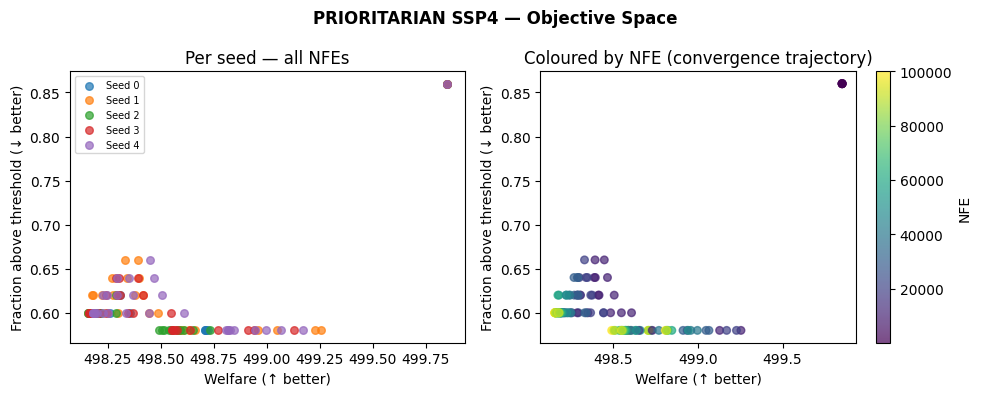

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Per-seed scatter (colour by seed)
seeds = df_obj["seed"].unique()
colors = plt.cm.tab10.colors

ax = axes[0]
for i, seed in enumerate(seeds):
    d = df_obj[df_obj["seed"] == seed]
    ax.scatter(d["welfare"], d["fraction_above_threshold"],
               label=f"Seed {i}", alpha=0.7, s=30, color=colors[i])
ax.set_xlabel("Welfare (↑ better)")
ax.set_ylabel("Fraction above threshold (↓ better)")
ax.set_title("Per seed — all NFEs")
ax.legend(fontsize=7)

# Colour by NFE to see trajectory over time
ax = axes[1]
sc = ax.scatter(df_obj["welfare"], df_obj["fraction_above_threshold"],
                c=df_obj["nfe"], cmap="viridis", alpha=0.7, s=30)
plt.colorbar(sc, ax=ax, label="NFE")
ax.set_xlabel("Welfare (↑ better)")
ax.set_ylabel("Fraction above threshold (↓ better)")
ax.set_title("Coloured by NFE (convergence trajectory)")

plt.suptitle("PRIORITARIAN SSP4 — Objective Space", fontweight="bold")
plt.tight_layout()
plt.savefig("prioritarian_ssp4_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

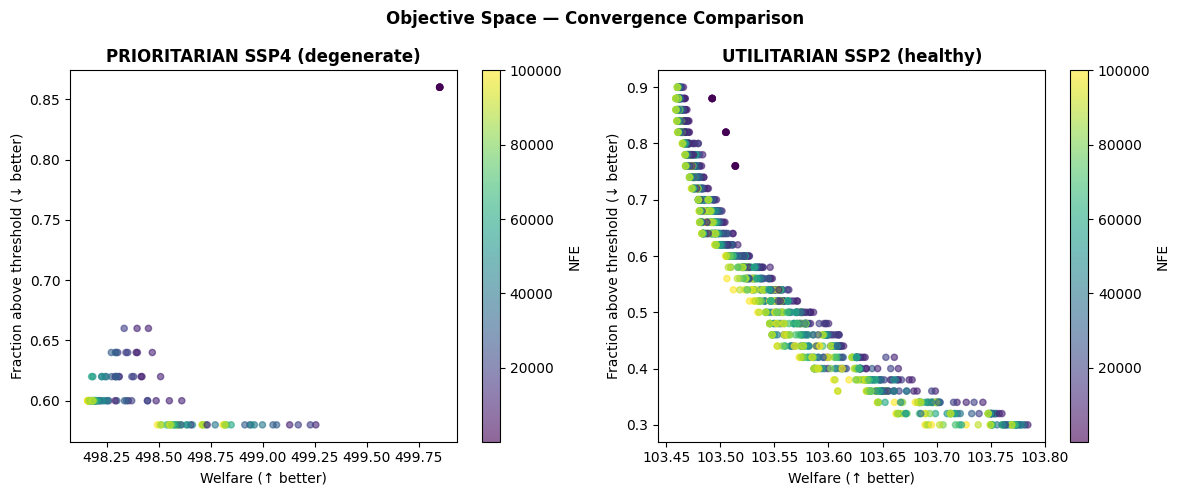

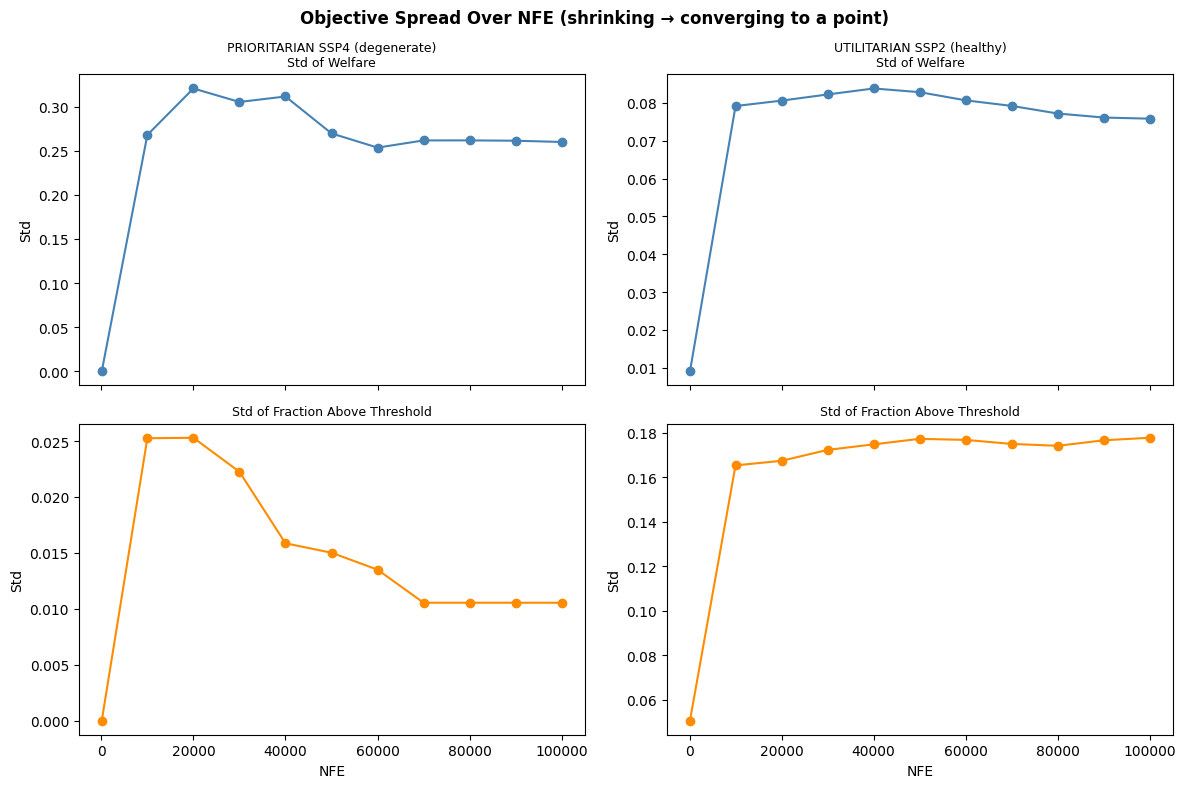

OBJECTIVE SPREAD AT FINAL NFE (100,000)

  PRIORITARIAN SSP4 (degenerate)
    n solutions       = 10
    welfare:
      std  = 0.259912
      range= 0.651665
    fraction_above_threshold:
      std  = 0.010541
      range= 0.020000

  UTILITARIAN SSP2 (healthy)
    n solutions       = 148
    welfare:
      std  = 0.075840
      range= 0.310210
    fraction_above_threshold:
      std  = 0.177770
      range= 0.600000


In [3]:
import tarfile, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

root = Path("data/temporary/NU_DATA/mmBorg/reproduce")

def load_folder(folder):
    records = []
    for archive_path in sorted(folder.glob("*.tar.gz")):
        seed = archive_path.stem
        with tarfile.open(archive_path, "r:gz") as tar:
            for member in tar.getmembers():
                if not member.name.endswith(".csv"):
                    continue
                nfe_str = Path(member.name).stem
                try:
                    nfe = int(nfe_str)
                except ValueError:
                    continue
                f = tar.extractfile(member)
                if f is None:
                    continue
                df = pd.read_csv(io.TextIOWrapper(f))
                df["seed"] = seed
                df["nfe"]  = nfe
                records.append(df)
    return pd.concat(records, ignore_index=True)

df_pri_ssp4 = load_folder(root / "PRIORITARIAN_SSP4")
df_uti_ssp2 = load_folder(root / "UTILITARIAN_SSP2")

# ── Rename UTILITARIAN columns if different ───────────────────────────────────
# Check: print(df_uti_ssp2.columns.tolist()) first if unsure
obj_x = "welfare"
obj_y = "fraction_above_threshold"

datasets = {
    "PRIORITARIAN SSP4 (degenerate)": df_pri_ssp4,
    "UTILITARIAN SSP2 (healthy)":     df_uti_ssp2,
}

# ── FIGURE 1: Objective space scatter coloured by NFE ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, datasets.items()):
    sc = ax.scatter(df[obj_x], df[obj_y],
                    c=df["nfe"], cmap="viridis", alpha=0.6, s=20)
    plt.colorbar(sc, ax=ax, label="NFE")
    ax.set_xlabel("Welfare (↑ better)")
    ax.set_ylabel("Fraction above threshold (↓ better)")
    ax.set_title(name, fontweight="bold")

plt.suptitle("Objective Space — Convergence Comparison", fontweight="bold")
plt.tight_layout()
plt.savefig("objective_space_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── FIGURE 2: Spread (std) of each objective over NFE ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for col_i, (name, df) in enumerate(datasets.items()):
    spread = (df.groupby("nfe")[[obj_x, obj_y]]
                .std()
                .reset_index()
                .sort_values("nfe"))

    axes[0, col_i].plot(spread["nfe"], spread[obj_x],  marker="o", color="steelblue")
    axes[0, col_i].set_title(f"{name}\nStd of Welfare", fontsize=9)
    axes[0, col_i].set_ylabel("Std")

    axes[1, col_i].plot(spread["nfe"], spread[obj_y], marker="o", color="darkorange")
    axes[1, col_i].set_title(f"Std of Fraction Above Threshold", fontsize=9)
    axes[1, col_i].set_ylabel("Std")
    axes[1, col_i].set_xlabel("NFE")

plt.suptitle("Objective Spread Over NFE (shrinking → converging to a point)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("spread_over_nfe.png", dpi=150, bbox_inches="tight")
plt.show()

# ── QUANTITATIVE: Stats at final NFE (100k) ───────────────────────────────────
print("=" * 60)
print("OBJECTIVE SPREAD AT FINAL NFE (100,000)")
print("=" * 60)
for name, df in datasets.items():
    final = df[df["nfe"] == 100000]
    print(f"\n  {name}")
    print(f"    n solutions       = {len(final)}")
    for col in [obj_x, obj_y]:
        print(f"    {col}:")
        print(f"      std  = {final[col].std():.6f}")
        print(f"      range= {final[col].max() - final[col].min():.6f}")

   welfare  fraction_above_threshold                              seed
498.706994                      0.58 PRIORITARIAN_100000_ref5_42_0.tar
498.584385                      0.58 PRIORITARIAN_100000_ref5_42_1.tar
498.493236                      0.58 PRIORITARIAN_100000_ref5_42_2.tar
498.551984                      0.58 PRIORITARIAN_100000_ref5_42_3.tar
498.808927                      0.58 PRIORITARIAN_100000_ref5_42_4.tar
498.158275                      0.60 PRIORITARIAN_100000_ref5_42_0.tar
498.158580                      0.60 PRIORITARIAN_100000_ref5_42_1.tar
498.157262                      0.60 PRIORITARIAN_100000_ref5_42_2.tar
498.160973                      0.60 PRIORITARIAN_100000_ref5_42_3.tar
498.180659                      0.60 PRIORITARIAN_100000_ref5_42_4.tar
PRIORITARIAN SSP4 — REFERENCE SET
  Shape       : (2, 246)
  Columns     : ['center 0', 'center 1', 'center 2', 'center 3', 'center 4', 'center 5', 'center 6', 'center 7', 'radii 0', 'radii 1', 'radii 2', 'radii 3', 'ra

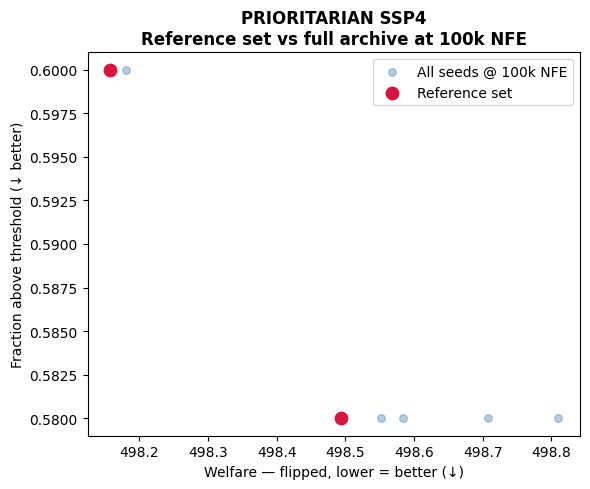

In [5]:
final_pri = df_pri_ssp4[df_pri_ssp4["nfe"] == 100000][[obj_x, obj_y, "seed"]].copy()
final_pri = final_pri.sort_values(obj_y)
print(final_pri[[obj_x, obj_y, "seed"]].to_string(index=False))


# ── Load and inspect reference set ───────────────────────────────────────────
ref_set = pd.read_csv(root / "PRIORITARIAN_SSP4" / "PRIORITARIAN_reference_set.csv")

print("=" * 60)
print("PRIORITARIAN SSP4 — REFERENCE SET")
print("=" * 60)
print(f"  Shape       : {ref_set.shape}")
print(f"  Columns     : {ref_set.columns.tolist()}")
print()
print(ref_set[[obj_x, obj_y]].sort_values(obj_y).to_string(index=False))

print()
print("  Objective spread in reference set:")
for col in [obj_x, obj_y]:
    print(f"    {col}:")
    print(f"      min   = {ref_set[col].min():.6f}")
    print(f"      max   = {ref_set[col].max():.6f}")
    print(f"      range = {ref_set[col].max() - ref_set[col].min():.6f}")
    print(f"      std   = {ref_set[col].std():.6f}")

# ── Plot reference set on top of full archive ─────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

final_pri = df_pri_ssp4[df_pri_ssp4["nfe"] == 100000]
ax.scatter(final_pri[obj_x], final_pri[obj_y],
           alpha=0.4, s=30, color="steelblue", label="All seeds @ 100k NFE")
ax.scatter(ref_set[obj_x], ref_set[obj_y],
           alpha=1.0, s=80, color="crimson", zorder=5, label="Reference set")

ax.set_xlabel("Welfare — flipped, lower = better (↓)")
ax.set_ylabel("Fraction above threshold (↓ better)")
ax.set_title("PRIORITARIAN SSP4\nReference set vs full archive at 100k NFE",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("prioritarian_ssp4_refset.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
for ssp in ["SSP1", "SSP2", "SSP3", "SSP4", "SSP5"]:
    folder = root / f"PRIORITARIAN_{ssp}"
    if not folder.exists():
        continue
    ref = pd.read_csv(folder / "PRIORITARIAN_reference_set.csv")
    frac_range = ref["fraction_above_threshold"].max() - ref["fraction_above_threshold"].min()
    print(f"  PRIORITARIAN {ssp}: n={len(ref):3d}  "
          f"fraction range={frac_range:.4f}  "
          f"welfare range={ref['welfare'].max()-ref['welfare'].min():.4f}")

  PRIORITARIAN SSP1: n=  4  fraction range=0.0600  welfare range=0.0420
  PRIORITARIAN SSP2: n= 10  fraction range=0.1800  welfare range=0.1396
  PRIORITARIAN SSP3: n=  5  fraction range=0.0800  welfare range=0.2094
  PRIORITARIAN SSP4: n=  2  fraction range=0.0200  welfare range=0.3360
  PRIORITARIAN SSP5: n=  8  fraction range=0.1400  welfare range=0.0893


# MATRIX PLOTS

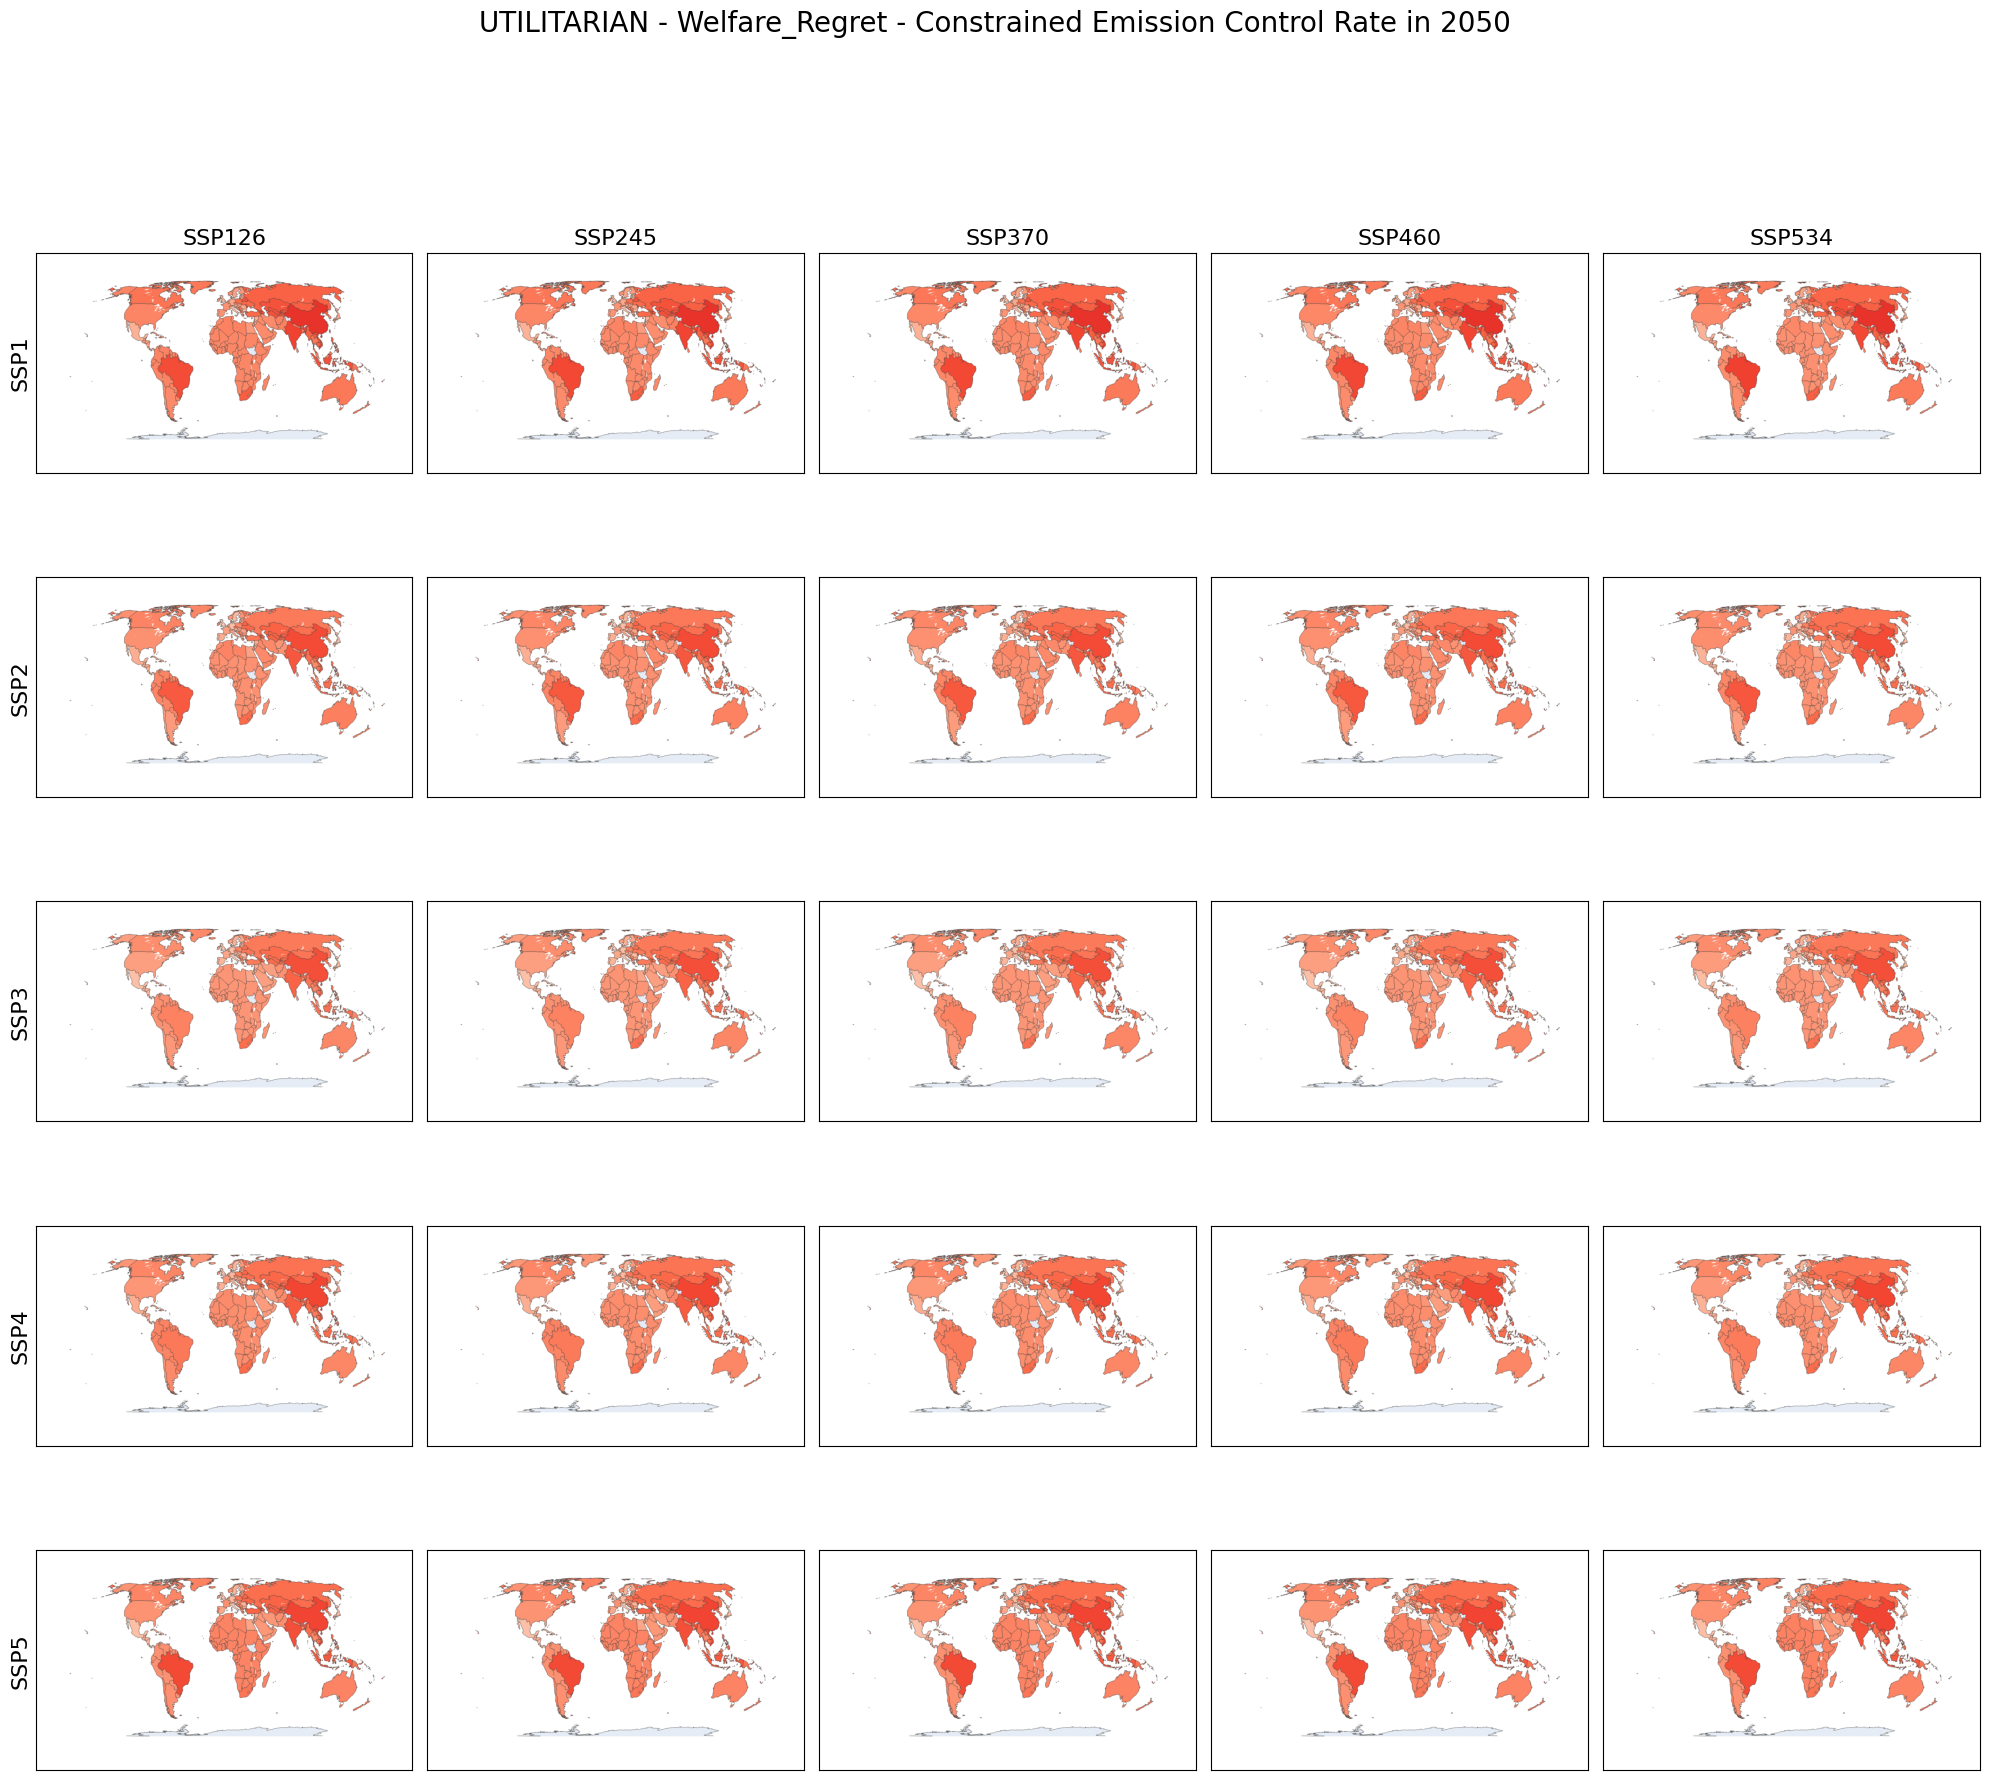

In [ ]:
# This code generates a 5x5 grid of choropleth plots.
# Rows correspond to reference_scenarios and columns to ssps.
# We add rotated row labels on the left and keep column labels on top.

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import json

regret_type = "Welfare_Regret"  # or "Welfare_Regret" "Temperature_Regret"
ethical_framing = "UTILITARIAN"  # or "UTILITARIAN"

fig, axs = plt.subplots(5, 5, figsize=(20, 20))

# Row labels (left side) correspond to reference scenarios
reference_scenarios = ["SSP1", "SSP2", "SSP3", "SSP4", "SSP5"]
# Column headers (top) correspond to SSPs
ssps = ["SSP126", "SSP245", "SSP370", "SSP460", "SSP534"]

base_path = "data/temporary/NU_DATA/mmBorg/plots/"

# Read the json file with min regret policy indices
with open("data/temporary/NU_DATA/mmBorg/min_regret_policy_indices.json", "r") as f:
    loaded_min_regret_policy_indices = json.load(f)

# Fill the grid with the plots
for i, scenario in enumerate(reference_scenarios):
    for j, ssp in enumerate(ssps):
        policy_index = loaded_min_regret_policy_indices[scenario][ethical_framing][regret_type]
        # Example file name: PRIORITARIAN_ref_SSP1_Welfare_Regret_idx0_SSP534_rate2050.png
        file_name = f"{ethical_framing}_ref_{scenario}_{regret_type}_idx{policy_index}_{ssp}_rate2050.png"
        img_path = os.path.join(base_path, file_name)

        try:
            img = mpimg.imread(img_path)
        except FileNotFoundError:
            print(f"Warning: missing {img_path}")
            continue

        ax = axs[i, j]
        ax.imshow(img)

        # Do not turn the axis completely off; hide only the ticks for a clean look
        ax.set_xticks([])
        ax.set_yticks([])

        # Column headers (SSP names) on the top row
        if i == 0:
            ax.set_title(ssp, fontsize=16)

        # Row labels on the left (will be set below)

# Row labels on the left (rotated 90 degrees by default)
for i, scenario in enumerate(reference_scenarios):
    axs[i, 0].set_ylabel(scenario, fontsize=16)

# Improve layout and give space for left labels
plt.subplots_adjust(left=0.28, right=0.98, top=0.95, bottom=0.08)

# Optional: only show outer labels (keeps the left column labels visible)
for ax in axs.flat:
    ax.label_outer()

plt.suptitle(f"{ethical_framing} - {regret_type} - Constrained Emission Control Rate in 2050", fontsize=20)

# Use tight_layout with a rect to avoid overlapping the suptitle
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save and display
output_pdf = os.path.join(base_path, f"{ethical_framing}_{regret_type}_constrained_emission_control_rate_2050_matrix.pdf")
plt.savefig(output_pdf)
plt.show()